# 🚗 IBM Fuel Consumption - Simple Linear Regression

## 📌 Objective
The goal is to build a **simple linear regression model** to predict fuel consumption based on engine size (or another predictor variable) using the **IBM Fuel Consumption dataset**.

---

## 📂 Dataset
- **Source**: IBM dataset (FuelConsumption.csv)  
- **Key Features**:
  - `ENGINESIZE` → Size of the car’s engine (liters)  
  - `CYLINDERS` → Number of cylinders  
  - `FUELCONSUMPTION_COMB` → Combined fuel consumption (L/100 km)  
  - `CO2EMISSIONS` → CO₂ emissions (g/km)  

---

## 📊 Exploratory Data Analysis (EDA)
1. Load dataset  
2. Check for missing values  
3. Visualize relationships (scatter plots, histograms)  


---

## 📈 Simple Linear Regression
We model the relationship between **engine size (X)** and **CO₂ emissions (Y)**:

$$
Y = b + m X
$$

- **Dependent variable (Y):** CO₂ emissions  
- **Independent variable (X):** Engine size  

---

## ⚙️ Steps
1. Split data into **training (80%)** and **testing (20%)** sets  
2. Fit a simple linear regression model  
3. Extract coefficients (`b`, `m`)  
4. Evaluate with metrics:  
   - Mean Absolute Error (MAE)  
   - Mean Squared Error (MSE)  
   - R² Score  

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Verify successful load with some randomly slected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
252,2014,CHEVROLET,SONIC 5,MID-SIZE,1.4,4,M6,X,8.5,6.2,7.5,38,172
918,2014,RAM,1500 FFV,PICKUP TRUCK - STANDARD,3.6,6,A8,E,19.4,13.6,16.8,17,269
804,2014,MINI,JOHN COOPER WORKS CLUBMAN,SUBCOMPACT,1.6,4,A6,Z,9.3,7.0,8.3,34,191
171,2014,CADILLAC,CTS SPORT WAGON AWD,STATION WAGON - SMALL,3.0,6,AS6,X,12.8,9.1,11.1,25,255
14,2014,ASTON MARTIN,V8 VANTAGE,TWO-SEATER,4.7,8,AM7,Z,17.4,11.3,14.7,19,338


In [6]:
# Explore the date
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
# Select features that might be indicative of CO2 emission
cdf = df[['CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
cdf.sample(9)

,CYLINDERS,ENGINESIZE,FUELCONSUMPTION_COMB,CO2EMISSIONS
557,8,5.0,17.5,280
776,8,5.5,10.7,246
68,8,4.0,12.9,297
235,4,2.4,10.6,244
848,6,3.5,10.9,251
1063,6,3.2,11.5,264
906,6,3.0,11.3,260
220,8,5.3,21.5,344
719,4,2.0,9.6,221


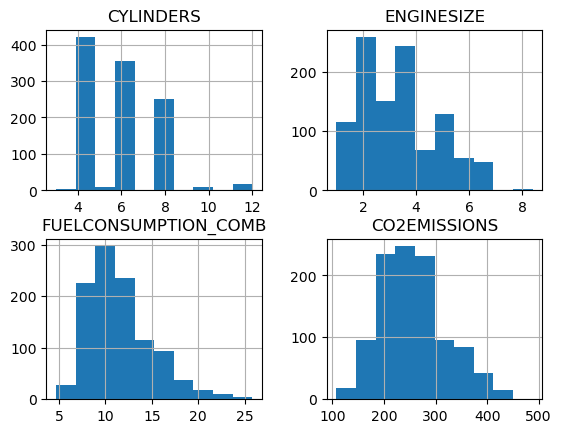

In [16]:
# Visualize features
viz = cdf[['CYLINDERS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist()
plt.show()

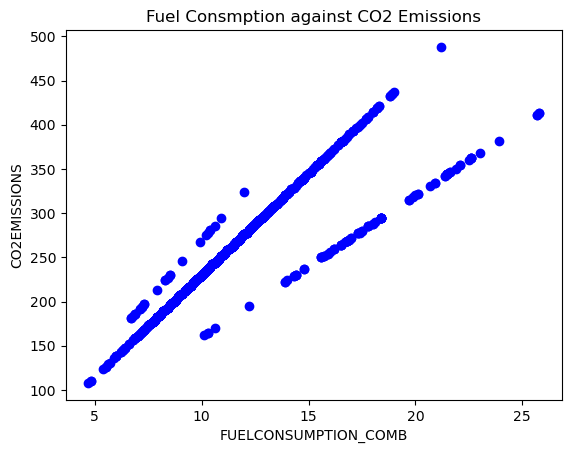

In [ ]:
# Visualize Fuel Consumption against CO2 emissions
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.title("Fuel Consmption against CO2 Emissions")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.show()

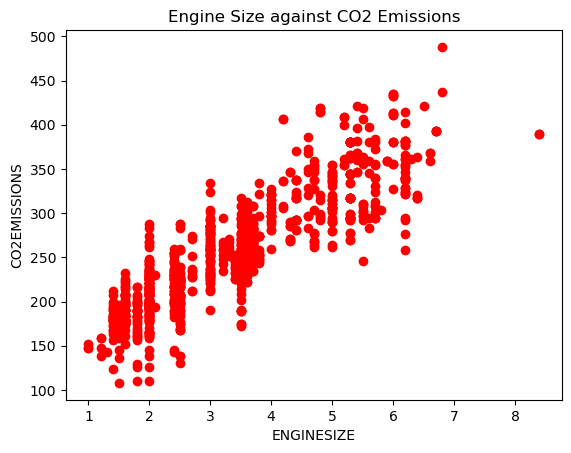

In [20]:
# Visualize engine size against CO2 emissions
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color="red")
plt.title("Engine Size against CO2 Emissions")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

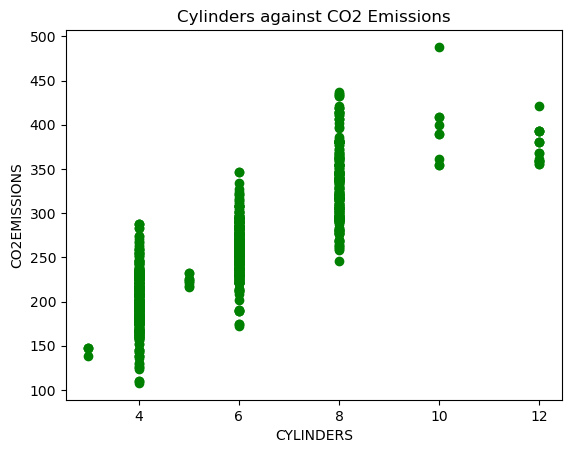

In [22]:
# Visualize cylinder against CO2 emissions
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color="green")
plt.title("Cylinders against CO2 Emissions")
plt.xlabel("CYLINDERS")
plt.ylabel('CO2EMISSIONS')
plt.show()

In [39]:
# Extract the input feature and labels from dataset
X = cdf[['ENGINESIZE']].to_numpy()
y = cdf['CO2EMISSIONS'].to_numpy()

Weight:  38.99297872443396
Intercept:  126.28970217408761


Text(0, 0.5, 'CO2 Emissions')

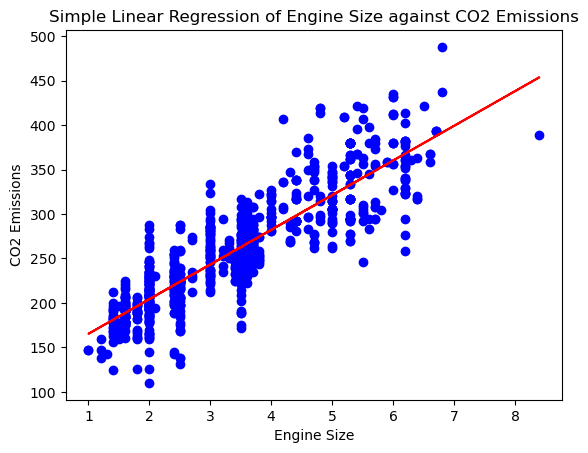

In [48]:
# Build a simple linear regression model
from sklearn.linear_model import LinearRegression

# Create model object
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Print the weight m and intercept b
print("Weight: ", model.coef_[0])
print("Intercept: ", model.intercept_)

# Make predictions
y_pred = model.predict(X_test)

# Visualize model outputs
plt.scatter(X_train, y_train, color="blue")
plt.plot(X_train, model.coef_[0] * X_train + model.intercept_, color="red")
plt.title("Simple Linear Regression of Engine Size against CO2 Emissions")
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")

In [50]:
# Model evaluation
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)
print("Intercept b: ", model.intercept_)
print("Weight m: ", model.coef_[0])

Mean Squared Error:  985.9381692275002
R2 Score:  0.7615595731934371
Intercept b:  126.28970217408761
Weight m:  38.99297872443396
